# 03MIAR - Algoritmos de optimización
## Actividad guiada 3

Docente :*David Álvarez Robles*
 - Estudiante: *Samuel Campozano lopez*
<br>

Link: https://drive.google.com/drive/folders/1Gt9xf7CmIurAruccFo7B-ybr27pv3XIX?usp=sharing <br>

Github: https://github.com/samuelbetzler/Algoritmos-de-Optimizacion
<br>


## Presentación

Profesor:
- Grupos A2, A3, B1, B2: David Álvarez Robles (dalvarezr@professor.universidadviu.com)

## Objetivos
- Comprender el uso de librerías de simulación del problema del agente viajero en Python
- Implementar y visualizar algoritmos de búsqueda basados en metaheurísticas
- Algoritmo de búsqueda aleatoria
- Algoritmo de búsqueda local
- Algoritmo Simulated Annealing

## Librerías y simulación del problema del agente viajero en Python
- Uso de librería tsplib95
- Visualización de datos

In [4]:
!pip install tsplib95
import tsplib95
import random
from math import e
import math
import copy
import urllib.request

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 8.2 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.2.1
    Uninstalling wrapt-2.2.1:
      Successfully uninstalled wrapt-2.2.1
  Attempting uninstall: tabulate
    Found existing installation: tabulate 0.9.0
    Uninstalling tabulate-0.9.0:
      Successfully uninstalled tabulate-0.9.0
  Attempting uninstall: networkx
    Found existing installation: networkx 3.6.1
    Uninstalling networkx-3.6.1:
      Successfully uninstalled networkx-3.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
momepy 0.11.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
bigframes 2.42.0 requires tabulate>=0.9, but you have tabulate 0.8.10 which is incompatible.
mapclassify 2.10.0 r

In [5]:
# Descargamos el fichero de datos (Matriz de distancias)
file = "swiss42.tsp" ;
urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )

#urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file + '.gz')
#!gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)


#http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/

('swiss42.tsp', <http.client.HTTPMessage at 0x7828e43b0080>)

In [6]:
problema = tsplib95.load(file)
nodos = list(problema.get_nodes())
aristas = list(problema.get_edges())

print(problema) # Descripción estándar
print(nodos) # Nodos 0, 1, 2 ... 42
print(aristas) # Ver https://github.com/mastqe/tsplib/blob/master/swiss42.tsp

NAME: swiss42
COMMENT: 42 Staedte Schweiz (Fricker)
TYPE: TSP
DIMENSION: 42
EDGE_WEIGHT_TYPE: EXPLICIT
EDGE_WEIGHT_FORMAT: FULL_MATRIX
EDGE_WEIGHT_SECTION:
0 15 30 23 32 55 33 37 92 114 92 110 96 90 74 76 82 67 72 78 82 159 122 131 206 112 57 28 43 70 65 66 37 103 84 125 129 72 126 141 183 124
15 0 34 23 27 40 19 32 93 117 88 100 87 75 63 67 71 69 62 63 96 164 132 131 212 106 44 33 51 77 75 72 52 118 99 132 132 67 139 148 186 122
30 34 0 11 18 57 36 65 62 84 64 89 76 93 95 100 104 98 57 88 99 130 100 101 179 86 51 4 18 43 45 95 45 115 93 152 159 100 112 114 153 94
23 23 11 0 11 48 26 54 70 94 69 89 75 84 84 89 92 89 54 78 99 141 111 109 190 89 44 11 29 54 56 89 47 118 96 147 151 90 122 126 163 101
32 27 18 11 0 40 20 58 67 92 61 78 65 76 83 89 91 95 43 72 110 141 116 105 190 81 34 19 35 57 63 97 58 129 107 156 158 92 129 127 161 95
55 40 57 48 40 0 23 55 96 123 78 75 62 36 56 66 63 95 37 34 137 174 156 129 224 90 15 59 75 96 103 105 91 158 139 164 156 78 169 163 191 115
33 19 36 26 20 

23


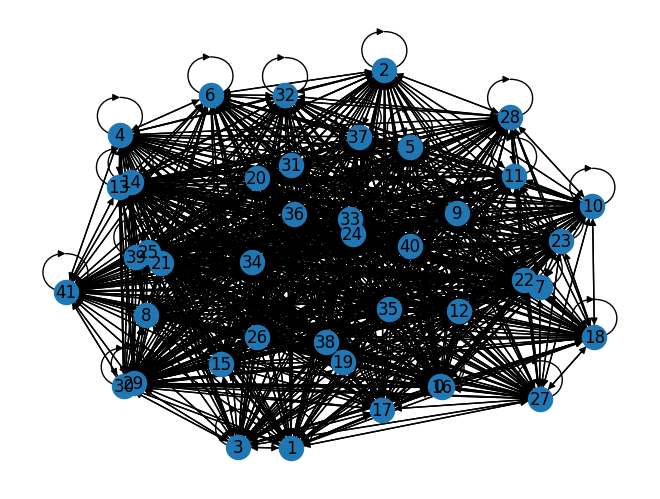

In [7]:
# Probamos algunas funciones del objeto problema, que ya nos vienen dadas

# Distancia entre nodos (ciudades)
distancia = problema.get_weight(3, 0)
print(distancia)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
#dir(problema)

import networkx as nx
import matplotlib.pyplot as plt
nx.draw(problema.get_graph(), with_labels=True, arrows=True)
plt.show()

In [8]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo TSP con solución específica")
    plt.show()

## Funciones básicas para algoritmos de búsqueda

In [9]:
# Genera una solución aleatoria con comienzo en en el nodo 0
def crear_solucion(nodos):
    # Nodo inicial = 0
    solucion = [nodos[0]]
    # Para el resto de nodos, los recorremos e incluimos aleatoriamente en la solución cada uno de ellos
    for n in nodos[1:]:
        # Debemos quitar el nodo 0 y los ya incluidos en cada iteración
        solucion = solucion + [random.choice(list(set(nodos) - set({nodos[0]}) - set(solucion)))]
    return solucion


# Devuelve la distancia entre dos nodos aprovechando la función get_weight() de tsplib95
def distancia(a,b, problema):
    return problema.get_weight(a,b)


# Devuelve la distancia total de una trayectoria/solución
def distancia_total(solucion, problema):
    distancia_total = 0
    # Para cada nodo de la solución calculamos su distancia a siguiente nodo
    for i in range(len(solucion)-1):
        distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problema)
    # Devolvemos la distancia total más la distancia del último nodo al primero para cerrar viaje
    return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problema)


solucion = crear_solucion(nodos)
print(solucion)
print(distancia_total(solucion, problema))

[0, 41, 2, 5, 38, 17, 39, 26, 28, 3, 16, 7, 10, 1, 24, 23, 19, 25, 33, 12, 36, 30, 11, 29, 40, 32, 18, 21, 22, 35, 14, 13, 9, 34, 6, 8, 20, 31, 27, 4, 15, 37]
5010


## Búsqueda aleatoria - TSP
- El algoritmo inicializa soluciones al azar y se queda con la mejor que encuentre
- Se realizan N iteraciones y nos quedamos con la mejor
- Todo es azar, sin que garanticemos solución óptima

Solución: [0, 29, 8, 25, 11, 21, 22, 3, 12, 32, 14, 26, 9, 28, 10, 38, 19, 16, 1, 13, 15, 17, 36, 34, 20, 33, 6, 27, 24, 18, 37, 31, 7, 2, 40, 23, 39, 41, 30, 5, 4, 35]
Distancia: 3722


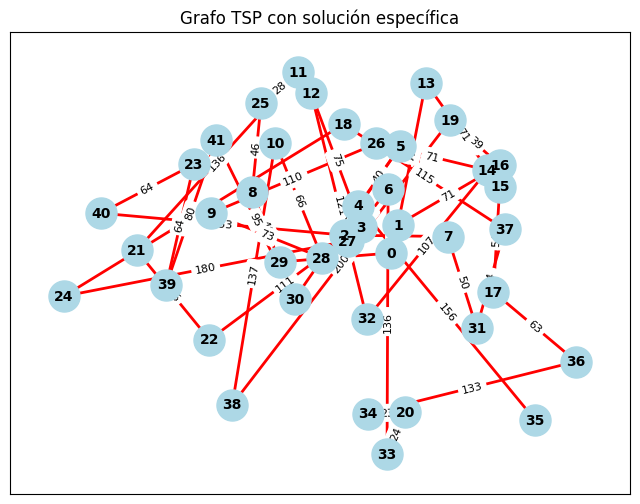

In [10]:
def busqueda_aleatoria(problema, iteraciones):
    # Obtenemos listado de nodos del problema
    nodos = list(problema.get_nodes())

    mejor_solucion = []
    mejor_distancia_total = float("inf")

    for i in range(iteraciones):
        # Generamos solución aleatoria
        solucion = crear_solucion(nodos)
        # Calculamos distancia total de la solución
        distancia = distancia_total(solucion, problema)
        if (distancia < mejor_distancia_total):
            mejor_solucion = solucion
            mejor_distancia_total = distancia

    return mejor_solucion, mejor_distancia_total

iteraciones = 5000
mejor_solucion, mejor_distancia_total = busqueda_aleatoria(problema, iteraciones)

print(f"Solución: {mejor_solucion}")
print(f"Distancia: {mejor_distancia_total}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)



## Búsqueda local - TSP
- El algoritmo se va quedando con vecinos (operadores de vecindad) para intentar converger a mejores soluciones
- Se realizan N iteraciones y nos quedamos con la mejor

In [11]:
# Función que a partir de una solución genera la vecina óptima (es decir, la mejor vecina de todas las que existen)
def genera_mejor_vecina(solucion):
    # Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones en el bucle
    # Se puede modificar para aplicar otros generadores distintos que 2-opt como inversión, barajado...
    #print(solucion)

    mejor_solucion = []
    mejor_distancia = float("inf")

    #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for i in range(1,len(solucion)-1):
        for j in range(i+1, len(solucion)):
            # Generamos nueva solución vecina (0, 1, 2, 3, i, ..., j, ..., 41) -> (0, 1, 2, 3, j, ..., i, ..., 41)
            vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

            # Se evalua la nueva solución
            distancia_vecina = distancia_total(vecina, problema)

            # Si es la mejor solución, la almacenamos
            if (distancia_vecina <= mejor_distancia):
                mejor_distancia = distancia_vecina
                mejor_solucion = vecina

    # Devolvemos mejor vecina
    return mejor_solucion


solucion = crear_solucion(nodos)
print(f"Distancia Solucion Incial: {distancia_total(solucion, problema)}")

nueva_solucion = genera_mejor_vecina(solucion)
print(f"Distancia Mejor Solucion Local: {distancia_total(nueva_solucion, problema)}")

Distancia Solucion Incial: 4776
Distancia Mejor Solucion Local: 4375


En la iteracion 31 la mejor solución encontrada es: [0, 12, 25, 41, 23, 8, 28, 30, 29, 9, 39, 22, 38, 33, 20, 35, 36, 31, 17, 37, 15, 16, 14, 7, 1, 6, 4, 3, 2, 27, 34, 32, 26, 5, 19, 13, 11, 40, 24, 21, 10, 18]
Distancia: 1881


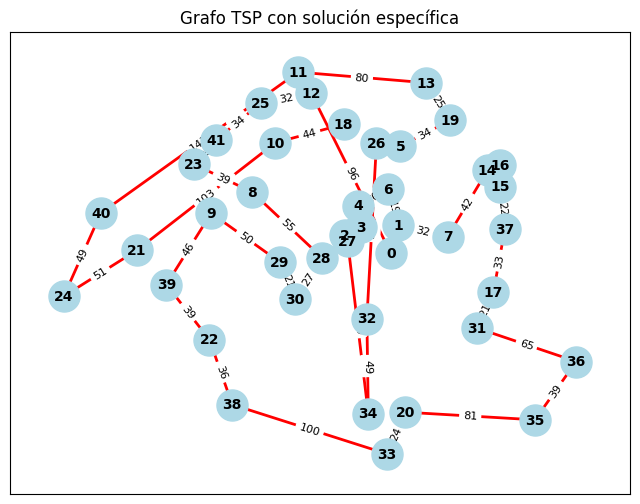

In [12]:
# En este caso, la búsqueda se ejecuta sin criterio de parada, se para cuando no es posible mejorar.
# Aquí iremos recorriendo las mejores vecinas para ir construyendo trayectoria
def busqueda_local(problema):
    mejor_solucion = []

    # Generar una solucion inicial de referencia(aleatoria)
    solucion_referencia = crear_solucion(nodos)
    mejor_distancia = distancia_total(solucion_referencia, problema)

    # Contador de iteraciones (por tener referencia)
    iteracion = 0

    while(1):
        iteracion += 1
        #print('#',iteracion)

        # Obtenemos la mejor vecina
        vecina = genera_mejor_vecina(solucion_referencia)

        # Evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
        distancia_vecina = distancia_total(vecina, problema)

        # Si mejoramos hay que seguir
        if (distancia_vecina < mejor_distancia):
            #mejor_solucion = copy.deepcopy(vecina)   # Con copia profunda. Las copias en python son por referencia
            mejor_solucion = vecina                   # Guarda la mejor solución encontrada
            mejor_distancia = distancia_vecina

        # Si no mejoramos, retornamos ya que hemos llegado a un minimo local (según nuestro operador de vecindad 2-opt)
        else:
            #print(f"En la iteracion {iteracion} la mejor solución encontrada es: {mejor_solucion}")
            #print(f"Distancia: {mejor_distancia}")
            return mejor_solucion, mejor_distancia, iteracion

        solucion_referencia = vecina


mejor_solucion, mejor_distancia, iteracion = busqueda_local(problema)
print(f"En la iteracion {iteracion} la mejor solución encontrada es: {mejor_solucion}")
print(f"Distancia: {mejor_distancia}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)

## Recocido simulado (Simulated Annealing) - TSP
- El algoritmo se va quedando con vecinos (operadores de vecindad) para intentar converger a mejores soluciones, aunque ahora a veces puedo elegir vecinos peores
- Al principio, elijo más veces vecinos peores (diversifico) y luego elijo menos veces esos vecinos peores (intensifico)
- Se realizan N iteraciones o bajamos temperatura al máximo

### Funciones auxiliares

In [13]:
# Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
def genera_vecina_aleatorio(solucion):

  # Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample(range(1,len(solucion)) , 2))

  # Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


# Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T, d):
  if random.random() <  math.exp(-1*d / T)  :
    return True
  else:
    return False


# Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.9999

La mejor solución encontrada es: [0, 28, 30, 29, 9, 8, 41, 23, 21, 40, 24, 39, 22, 38, 33, 35, 36, 7, 1, 6, 3, 27, 10, 25, 11, 12, 18, 26, 5, 13, 19, 14, 16, 15, 37, 17, 31, 20, 34, 32, 2, 4] en 207223 iteraciones
Distancia: 1539


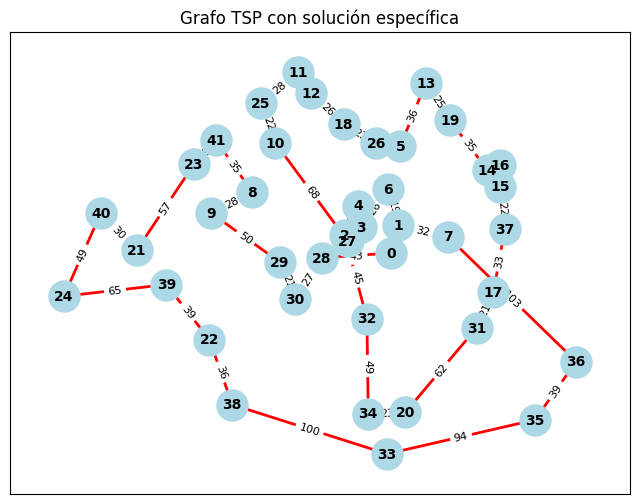

In [14]:
def recocido_simulado(problema, temperatura):
    # Generamos solución de referencia
    solucion_referencia = crear_solucion(nodos)
    distancia_referencia = distancia_total(solucion_referencia, problema)

    mejor_solucion = []
    mejor_distancia = float("inf")

    iteraciones = 0

    # Mientras la temperatura no sea 0 (aquí no hay parada por iteraciones)
    while temperatura > .0001:
        iteraciones += 1

        # Genera una solución vecina
        vecina = genera_vecina_aleatorio(solucion_referencia)

        # Calculamos distancia
        distancia_vecina = distancia_total(vecina, problema)

        # Si es la mejor solución de todas se guarda siempre
        if (distancia_vecina < mejor_distancia):
            mejor_solucion = vecina
            mejor_distancia = distancia_vecina

        # Si la nueva vecina es o
        # Si el vecino es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
        if ((distancia_vecina < distancia_referencia) or probabilidad(temperatura, abs(distancia_referencia - distancia_vecina))):
            #solucion_referencia = copy.deepcopy(vecina)
            solucion_referencia = vecina
            distancia_referencia = distancia_vecina

        # Bajamos la temperatura
        temperatura = bajar_temperatura(temperatura)

    return mejor_solucion, mejor_distancia, iteraciones

temperatura = 100000
mejor_solucion, mejor_distancia, iteraciones  = recocido_simulado(problema, temperatura)

print(f"La mejor solución encontrada es: {mejor_solucion} en {iteraciones} iteraciones")
print(f"Distancia: {mejor_distancia}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)

### Mejora de búsqueda local - Multiarranque
El algoritmo de búsqueda local básico tiene un problema fundamental: **queda atrapado en mínimos locales** que dependen enteramente del punto de partida inicial aleatorio. Cada ejecución puede converger a una solución distinta y no existe garantía de que sea la mejor.

La estrategia de **multiarranque** (o multi-start) soluciona esto lanzando la búsqueda local múltiples veces, cada una desde una solución inicial diferente generada aleatoriamente. Al final se comparan todos los mínimos locales encontrados y nos quedamos con el mejor.

**¿Por qué funciona mejor que un solo arranque?**
- Cada arranque explora una región distinta del espacio de soluciones
- Se reduce la dependencia del punto de partida inicial
- A mayor número de arranques, mayor probabilidad de encontrar un mínimo local de buena calidad
- El coste computacional crece de forma lineal con el número de arranques

Ejecutando búsqueda local con multiarranque (10 arranques)...

  Arranque 1/10 -> distancia local: 1654
  Arranque 2/10 -> distancia local: 1876
  Arranque 3/10 -> distancia local: 1736
  Arranque 4/10 -> distancia local: 1788
  Arranque 5/10 -> distancia local: 1880
  Arranque 6/10 -> distancia local: 1653
  Arranque 7/10 -> distancia local: 1772
  Arranque 8/10 -> distancia local: 1720
  Arranque 9/10 -> distancia local: 1677
  Arranque 10/10 -> distancia local: 1859

Mejor solución encontrada: [0, 6, 5, 19, 13, 26, 18, 4, 2, 39, 24, 40, 21, 10, 12, 11, 25, 41, 23, 9, 8, 29, 32, 31, 17, 36, 35, 20, 33, 34, 38, 22, 30, 28, 27, 3, 14, 16, 15, 37, 7, 1]
Mejor distancia (multiarranque): 1653


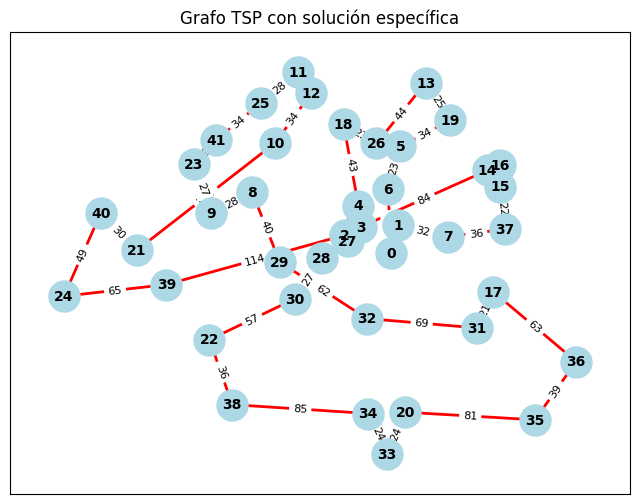

In [15]:
# ============================================================
# ACTIVIDAD EXTRA 1: BÚSQUEDA LOCAL CON MULTIARRANQUE
# Mejora de la búsqueda local básica mediante múltiples
# puntos de partida aleatorios independientes.
# En lugar de ejecutar la búsqueda local una sola vez,
# la repetimos N veces y nos quedamos con la mejor solución.
# ============================================================

def busqueda_local_multiarranque(problema, num_arranques):
    """
    Ejecuta la búsqueda local 'num_arranques' veces desde
    soluciones iniciales aleatorias distintas.
    Devuelve la mejor solución encontrada en todos los arranques.
    """
    nodos = list(problema.get_nodes())
    mejor_solucion_global = []
    mejor_distancia_global = float("inf")

    for arranque in range(num_arranques):
        # Generamos una solución inicial aleatoria diferente en cada arranque
        solucion_referencia = crear_solucion(nodos)
        mejor_distancia_local = distancia_total(solucion_referencia, problema)

        # Búsqueda local desde este punto de partida (igual que la original)
        while True:
            vecina = genera_mejor_vecina(solucion_referencia)
            distancia_vecina = distancia_total(vecina, problema)

            if distancia_vecina < mejor_distancia_local:
                # Si la vecina mejora, avanzamos hacia ella
                solucion_referencia = vecina
                mejor_distancia_local = distancia_vecina
            else:
                # Mínimo local alcanzado: este arranque termina
                break

        # Comparamos el mínimo local de este arranque con el mejor global
        if mejor_distancia_local < mejor_distancia_global:
            mejor_solucion_global = solucion_referencia
            mejor_distancia_global = mejor_distancia_local

        print(f"  Arranque {arranque+1}/{num_arranques} -> distancia local: {mejor_distancia_local}")

    return mejor_solucion_global, mejor_distancia_global


# Ejecutamos el multiarranque con 10 arranques
num_arranques = 10
print(f"Ejecutando búsqueda local con multiarranque ({num_arranques} arranques)...\n")
mejor_solucion_ms, mejor_distancia_ms = busqueda_local_multiarranque(problema, num_arranques)

print(f"\nMejor solución encontrada: {mejor_solucion_ms}")
print(f"Mejor distancia (multiarranque): {mejor_distancia_ms}")

plot_tsp_solution(problema.edge_weights, mejor_solucion_ms)

### Mejora de búsqueda local - Búsqueda en Entornos Variables (VNS)
La **Búsqueda en Entornos Variables**  amplía la búsqueda local usando **múltiples operadores de vecindad** en lugar de uno solo (2-opt).

La idea clave es que cuando la búsqueda se estanca en un mínimo local con un operador, se cambia a otro operador de vecindad distinto (e.g. 3-opt, inversión de segmento) para intentar escapar. Si se encuentra mejora, se vuelve al primer operador.

**Entornos de vecindad implementados:**
- **2-opt**: intercambia la posición de dos nodos cualesquiera
- **3-opt (or-opt)**: extrae un nodo y lo reinserta en otra posición del recorrido
- **Inversión de segmento**: invierte el orden de un segmento completo del recorrido

Ejecutando Búsqueda en Entornos Variables (VNS)...

  Iter 1: mejora con '2-opt' -> dist=4606
  Iter 2: mejora con '2-opt' -> dist=4245
  Iter 3: mejora con '2-opt' -> dist=3938
  Iter 4: mejora con '2-opt' -> dist=3689
  Iter 5: mejora con '2-opt' -> dist=3442
  Iter 6: mejora con '2-opt' -> dist=3201
  Iter 7: mejora con '2-opt' -> dist=3042
  Iter 8: mejora con '2-opt' -> dist=2945
  Iter 9: mejora con '2-opt' -> dist=2861
  Iter 10: mejora con '2-opt' -> dist=2773
  Iter 11: mejora con '2-opt' -> dist=2714
  Iter 12: mejora con '2-opt' -> dist=2661
  Iter 13: mejora con '2-opt' -> dist=2595
  Iter 14: mejora con '2-opt' -> dist=2553
  Iter 15: mejora con '2-opt' -> dist=2512
  Iter 16: mejora con '2-opt' -> dist=2474
  Iter 17: mejora con '2-opt' -> dist=2438
  Iter 18: mejora con '2-opt' -> dist=2393
  Iter 19: mejora con '2-opt' -> dist=2358
  Iter 20: mejora con '2-opt' -> dist=2324
  Iter 21: mejora con '2-opt' -> dist=2293
  Iter 22: mejora con '2-opt' -> dist=2216
  Iter 23: 

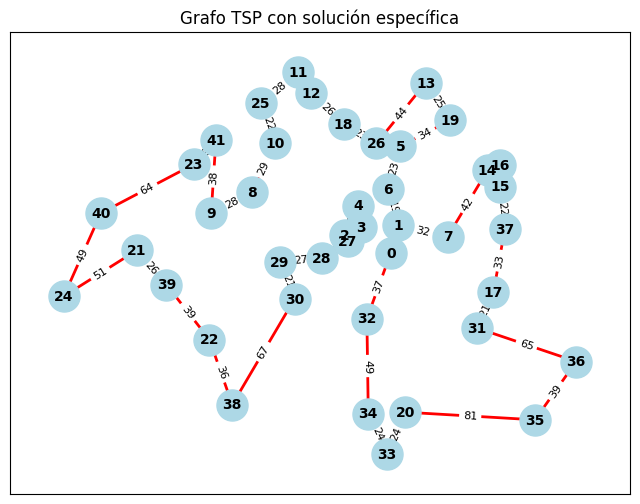

In [16]:
# ============================================================
# ACTIVIDAD EXTRA 2: BÚSQUEDA EN ENTORNOS VARIABLES (VNS)
# En lugar de usar solo 2-opt, definimos 3 operadores de
# vecindad distintos. Cuando la búsqueda se estanca con uno,
# prueba el siguiente hasta mejorar o agotar todos.
# ============================================================

# --- OPERADOR 1: 2-opt (el mismo que ya conocemos) ---
# Intercambia la posición de dos nodos i y j en la solución
def vecindad_2opt(solucion):
    """Devuelve la mejor vecina por intercambio 2-opt"""
    mejor_sol = solucion[:]
    mejor_dist = distancia_total(solucion, problema)
    for i in range(1, len(solucion) - 1):
        for j in range(i + 1, len(solucion)):
            vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]
            d = distancia_total(vecina, problema)
            if d < mejor_dist:
                mejor_dist = d
                mejor_sol = vecina
    return mejor_sol, mejor_dist

# --- OPERADOR 2: Or-opt (reinserción de un nodo en otra posición) ---
# Extrae un nodo y lo inserta en la mejor posición disponible
def vecindad_or_opt(solucion):
    """Devuelve la mejor vecina por reinserción de 1 nodo (or-opt)"""
    mejor_sol = solucion[:]
    mejor_dist = distancia_total(solucion, problema)
    for i in range(1, len(solucion)):           # nodo a extraer (no el 0)
        nodo = solucion[i]
        sin_nodo = solucion[:i] + solucion[i+1:]  # solución sin el nodo i
        for j in range(1, len(sin_nodo)):          # posición de inserción
            vecina = sin_nodo[:j] + [nodo] + sin_nodo[j:]
            d = distancia_total(vecina, problema)
            if d < mejor_dist:
                mejor_dist = d
                mejor_sol = vecina
    return mejor_sol, mejor_dist

# --- OPERADOR 3: Inversión de segmento ---
# Invierte el orden de un segmento [i..j] del recorrido
def vecindad_inversion(solucion):
    """Devuelve la mejor vecina invirtiendo un segmento del recorrido"""
    mejor_sol = solucion[:]
    mejor_dist = distancia_total(solucion, problema)
    for i in range(1, len(solucion) - 1):
        for j in range(i + 2, len(solucion) + 1):
            vecina = solucion[:i] + solucion[i:j][::-1] + solucion[j:]
            d = distancia_total(vecina, problema)
            if d < mejor_dist:
                mejor_dist = d
                mejor_sol = vecina
    return mejor_sol, mejor_dist

# Lista de operadores y sus nombres
ENTORNOS = [vecindad_2opt, vecindad_or_opt, vecindad_inversion]
NOMBRES_ENTORNOS = ["2-opt", "Or-opt (reinserción)", "Inversión de segmento"]

# --- ALGORITMO VNS ---
def busqueda_entornos_variables(problema):
    """
    Variable Neighbourhood Search (VNS):
    - Parte de una solución aleatoria.
    - Intenta mejorar con el entorno k=0 (2-opt).
    - Si mejora, reinicia k=0.
    - Si no mejora, pasa al siguiente entorno k+1.
    - Para cuando ningún entorno logra mejorar.
    """
    nodos = list(problema.get_nodes())
    solucion = crear_solucion(nodos)
    dist_actual = distancia_total(solucion, problema)

    iteracion = 0
    k = 0  # Índice del entorno actual

    while k < len(ENTORNOS):
        iteracion += 1
        vecina, dist_vecina = ENTORNOS[k](solucion)

        if dist_vecina < dist_actual:
            # Mejora encontrada: actualizamos y reiniciamos al primer entorno
            solucion = vecina
            dist_actual = dist_vecina
            print(f"  Iter {iteracion}: mejora con '{NOMBRES_ENTORNOS[k]}' -> dist={dist_actual}")
            k = 0  # Volvemos al entorno más básico
        else:
            # Sin mejora: probamos el siguiente entorno
            print(f"  Iter {iteracion}: sin mejora con '{NOMBRES_ENTORNOS[k]}', probando siguiente...")
            k += 1

    return solucion, dist_actual, iteracion


print("Ejecutando Búsqueda en Entornos Variables (VNS)...\n")
mejor_solucion_vns, mejor_distancia_vns, iters_vns = busqueda_entornos_variables(problema)

print(f"\nMejor solución VNS: {mejor_solucion_vns}")
print(f"Distancia VNS: {mejor_distancia_vns} (en {iters_vns} iteraciones)")

plot_tsp_solution(problema.edge_weights, mejor_solucion_vns)

### Recocido Simulado - Mejora en la Selección de Vecinos
En el recocido simulado original, la vecina se genera **completamente al azar** (función `genera_vecina_aleatorio`). Esto es muy rápido por iteración, pero genera vecinos de baja calidad que ralentizan la convergencia.

La mejora consiste en usar una **selección de vecinos guiada**: en lugar de elegir cualquier par de nodos al azar, elegimos un nodo al azar pero buscamos su **mejor intercambio posible** con otro nodo del recorrido. Así cada vecino generado tiene mayor probabilidad de mejorar la solución, reduciendo las iteraciones necesarias y mejorando la distancia final.

**Comparativa de estrategias de vecinos:**
- **Vecino aleatorio puro**: cualquier swap aleatorio → rápido pero poco informado
- **Vecino guiado (mejor swap de un nodo)**: evalúa todos los swaps del nodo elegido y devuelve el mejor → más informado, misma velocidad asintótica

SA ORIGINAL (vecino aleatorio puro)
Distancia final : 1514
Iteraciones     : 207223

SA MEJORADO (selección guiada de vecinos)
Distancia final : 1300
Iteraciones     : 207223

Mejora obtenida con selección guiada: 14.13%

Visualizando solución SA mejorado:


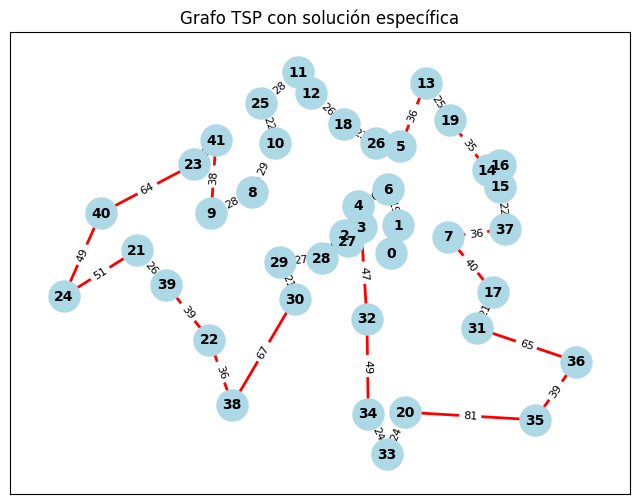

In [17]:
# ============================================================
# ACTIVIDAD EXTRA 3: RECOCIDO SIMULADO CON SELECCIÓN GUIADA
# Mejora la función genera_vecina_aleatorio() del SA original.
# En lugar de elegir dos nodos completamente al azar,
# elegimos UN nodo al azar y buscamos el MEJOR intercambio
# posible para ese nodo. Esto guía la búsqueda sin eliminar
# la aleatoriedad que le permite escapar de mínimos locales.
# ============================================================

def genera_vecina_guiada(solucion):
    """
    Mejora sobre genera_vecina_aleatorio():
    - Elige un nodo i al azar (distinto del nodo 0).
    - Evalúa todos los intercambios posibles del nodo i con cualquier j != i.
    - Devuelve el intercambio que produce la menor distancia total.
    Más informada que el swap ciego, mantiene la aleatoriedad del SA.
    """
    # Elegimos un nodo i al azar (nunca el nodo de inicio = posición 0)
    i = random.randint(1, len(solucion) - 1)
    mejor_vecina = solucion[:]
    mejor_dist = float("inf")

    # Evaluamos todos los posibles intercambios del nodo en posición i
    for j in range(1, len(solucion)):
        if j == i:
            continue
        vecina = solucion[:]
        vecina[i], vecina[j] = vecina[j], vecina[i]  # Intercambio i <-> j
        d = distancia_total(vecina, problema)
        if d < mejor_dist:
            mejor_dist = d
            mejor_vecina = vecina

    return mejor_vecina


def recocido_simulado_mejorado(problema, temperatura):
    """
    Igual que recocido_simulado(), pero usando genera_vecina_guiada()
    en lugar de genera_vecina_aleatorio(). La selección guiada produce
    vecinos de mayor calidad por iteración, mejorando la convergencia.
    """
    nodos = list(problema.get_nodes())
    solucion_referencia = crear_solucion(nodos)
    distancia_referencia = distancia_total(solucion_referencia, problema)
    mejor_solucion = solucion_referencia[:]
    mejor_distancia = distancia_referencia
    iteraciones = 0

    while temperatura > .0001:
        iteraciones += 1

        # CAMBIO CLAVE: vecino guiado en lugar de completamente aleatorio
        vecina = genera_vecina_guiada(solucion_referencia)
        distancia_vecina = distancia_total(vecina, problema)

        # Guardamos siempre la mejor solución global encontrada
        if distancia_vecina < mejor_distancia:
            mejor_solucion = vecina
            mejor_distancia = distancia_vecina

        # Criterio de aceptación de Metropolis (igual que el original)
        if (distancia_vecina < distancia_referencia or
                probabilidad(temperatura, abs(distancia_referencia - distancia_vecina))):
            solucion_referencia = vecina
            distancia_referencia = distancia_vecina

        # Enfriamiento geométrico (igual que el original)
        temperatura = bajar_temperatura(temperatura)

    return mejor_solucion, mejor_distancia, iteraciones


# --- COMPARATIVA: SA original vs SA mejorado ---
temperatura = 100000

print("=" * 60)
print("SA ORIGINAL (vecino aleatorio puro)")
print("=" * 60)
mejor_sol_sa_orig, mejor_dist_sa_orig, iters_sa_orig = recocido_simulado(problema, temperatura)
print(f"Distancia final : {mejor_dist_sa_orig}")
print(f"Iteraciones     : {iters_sa_orig}")

print("\n" + "=" * 60)
print("SA MEJORADO (selección guiada de vecinos)")
print("=" * 60)
mejor_sol_sa_mej, mejor_dist_sa_mej, iters_sa_mej = recocido_simulado_mejorado(problema, temperatura)
print(f"Distancia final : {mejor_dist_sa_mej}")
print(f"Iteraciones     : {iters_sa_mej}")

print("\n" + "=" * 60)
mejora_pct = (mejor_dist_sa_orig - mejor_dist_sa_mej) / mejor_dist_sa_orig * 100
print(f"Mejora obtenida con selección guiada: {mejora_pct:.2f}%")
print("=" * 60)

print("\nVisualizando solución SA mejorado:")
plot_tsp_solution(problema.edge_weights, mejor_sol_sa_mej)

## Conclusiones - Mejoras sobre la búsqueda local básica

A lo largo de esta actividad pudimos ver bastante claro cuál es el gran talón de Aquiles de la búsqueda local simple: da igual lo bien que funcione el algoritmo si la solución de partida es mala. Si empezamos desde un punto muy desfavorable, el algoritmo se queda atascado ahí y no hay manera de salir.

El **Multiarranque** ataca justo ese problema. La idea es sencilla: si un solo intento puede darnos mala suerte con el punto de partida, probamos varios. Ejecutamos la búsqueda local varias veces desde distintos puntos aleatorios y nos quedamos con el mejor resultado. No es nada sofisticado, pero funciona. El precio es que tarda más, claro, pero la mejora en la solución final hace que valga la pena.

La **Búsqueda en Entornos Variables (VNS)** va un poco más allá. En vez de repetir lo mismo desde distintos puntos, lo que hace es cambiar la forma de explorar el vecindario cuando se queda bloqueada. Si con 2-opt no hay mejora, prueba con or-opt; si tampoco, con inversión de segmento. Así tiene más herramientas para escapar de los mínimos locales sin necesidad de reiniciar desde cero.

Respecto al **Recocido Simulado con selección guiada de vecinos**, la diferencia es también bastante intuitiva. El SA original escoge sus vecinos completamente al azar, lo que hace que muchos de esos movimientos sean directamente malos y el algoritmo los descarte sin aprender nada. Al cambiar eso por una selección más inteligente, donde evaluamos varios intercambios posibles y elegimos el más prometedor, conseguimos que cada paso cuente más. El SA tarda algo más por iteración, pero las soluciones a las que llega son mejores.

En definitiva, lo que aprendimos aquí es que no siempre hace falta reinventar el algoritmo para obtener mejores resultados. A veces basta con ser un poco más inteligente a la hora de elegir por dónde moverse.